In [1]:
print("Antas")

Antas


In [2]:
!pip install -q lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


--- Initializing Data & Explainer ---

[INFO] Model feature mismatch detected (likely due to dropping 'Scalling').
Instantly retraining a fresh stealth model for XAI...

Calculating SHAP values (TreeExplainer)...
SHAP values ready! Generating 5 advanced graphs...



/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-4002240151.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


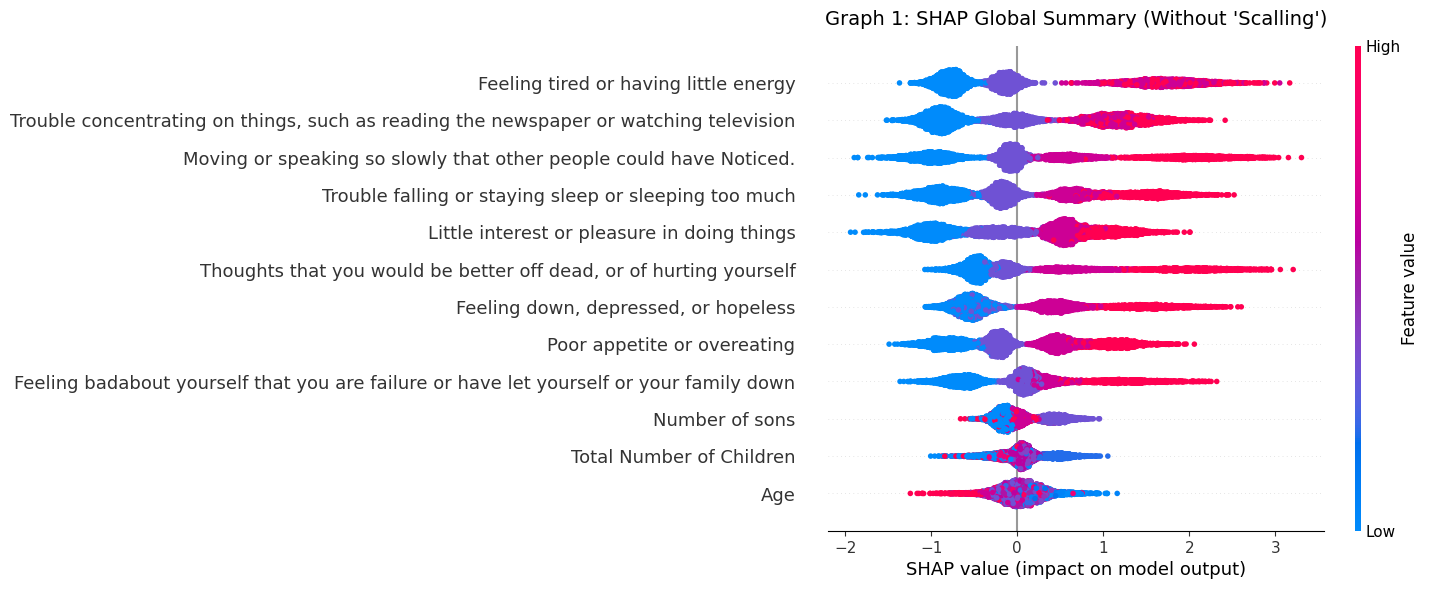

/tmp/ipython-input-4002240151.py:60: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


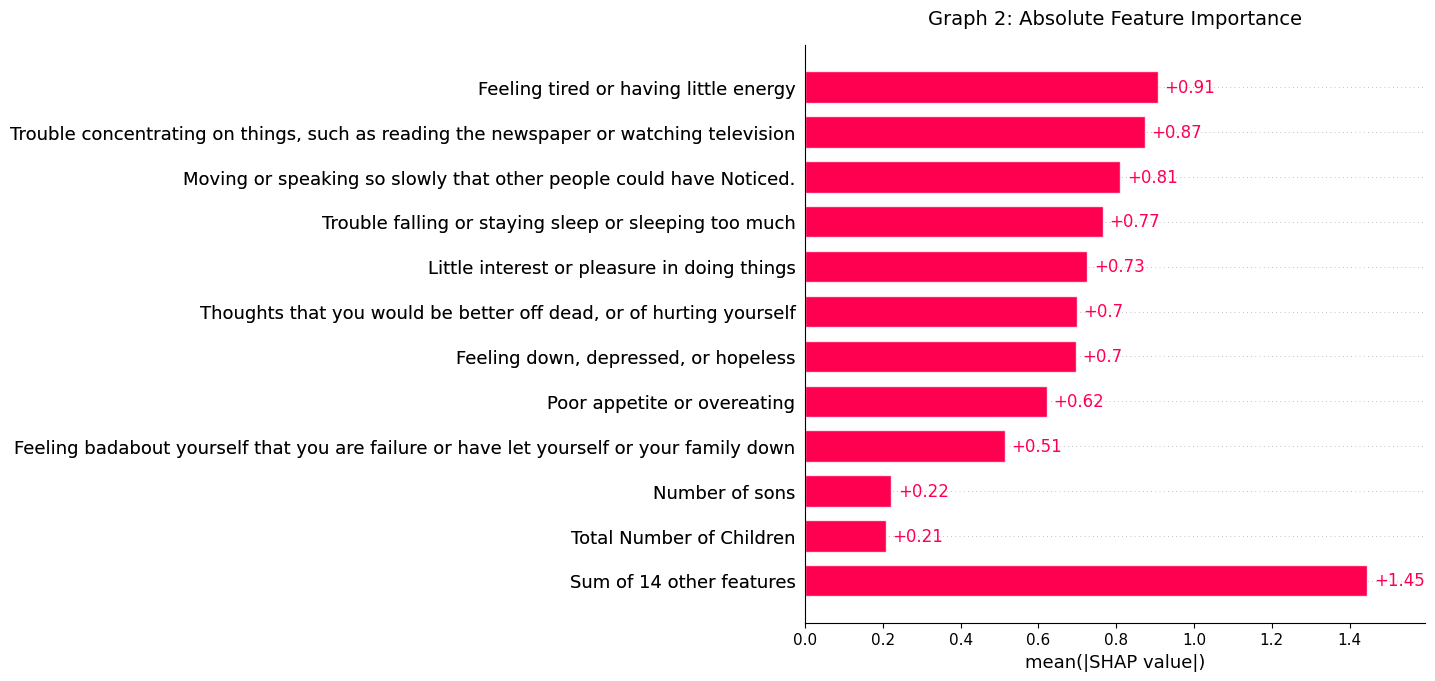

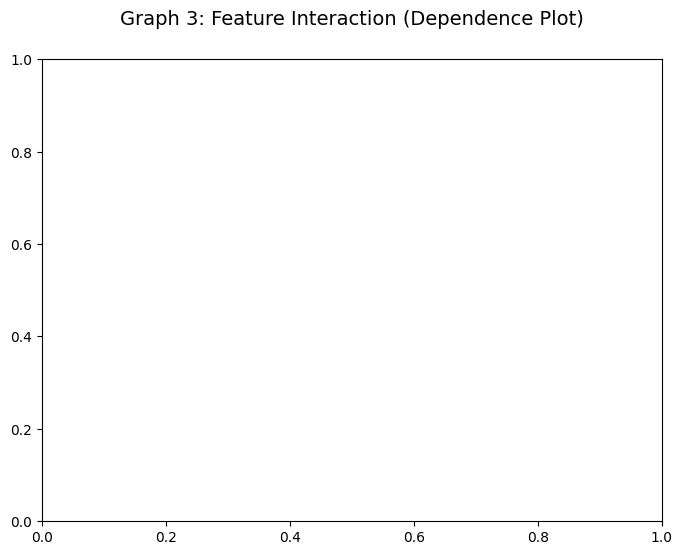

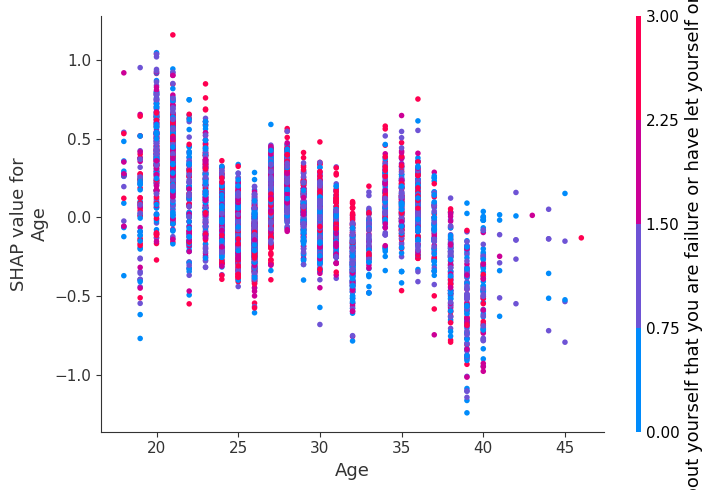

/tmp/ipython-input-4002240151.py:90: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


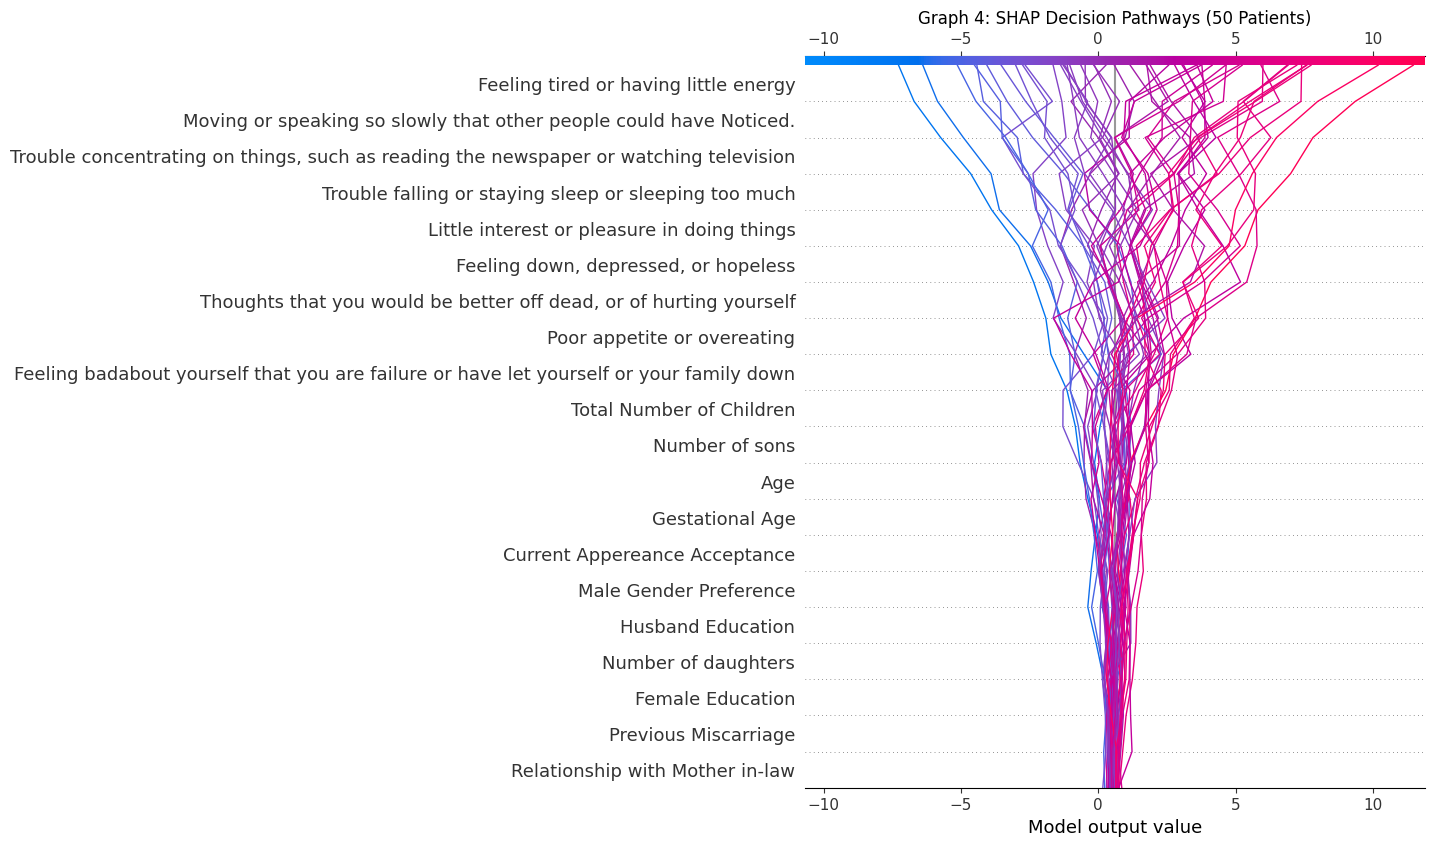

Generating LIME Explanation for Patient #0...


/tmp/ipython-input-4002240151.py:118: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


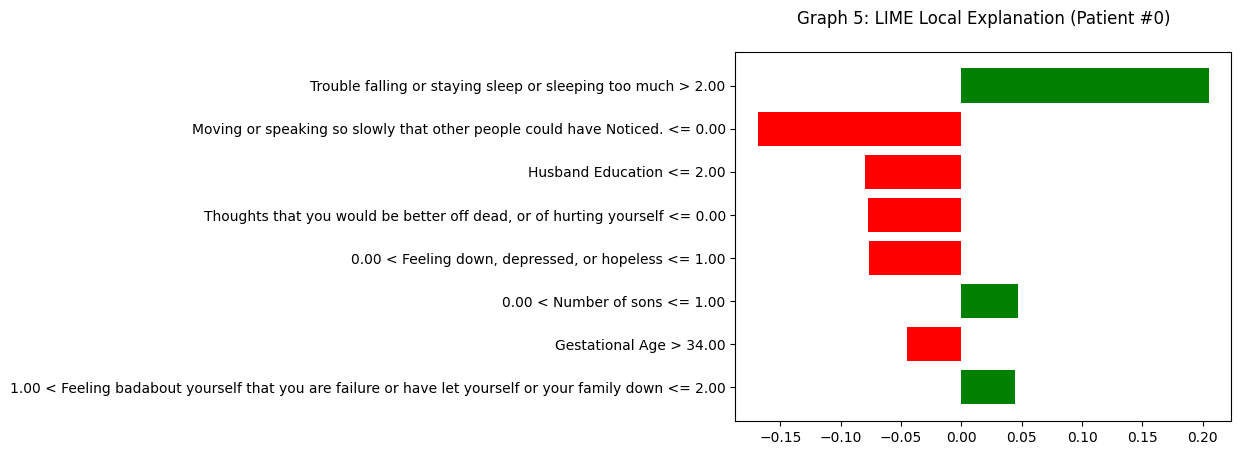


All 5 advanced XAI visualizations generated and saved!


In [3]:
# ==========================================
# MASTER XAI SUITE: Comprehensive Explainable AI
# ==========================================

import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
import xgboost as xgb
import numpy as np

print("--- Initializing Data & Explainer ---")

# 2. Load the Data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# DROP BOTH 'Labelling' AND 'Scalling'
X_train = train_data.drop(['Labelling', 'Scalling'], axis=1, errors='ignore')
y_train = train_data['Labelling']
X_test = test_data.drop(['Labelling', 'Scalling'], axis=1, errors='ignore')

# 3. Load or Retrain the Model
model_path = '/content/tab_transformer_opti.pkl'
model = joblib.load(model_path)

# 4. Calculate SHAP Values
print("Calculating SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
print("SHAP values ready! Generating 5 advanced graphs...\n")

# ==========================================
# GRAPH 1: Global Summary Plot (Beeswarm)
# ==========================================
plt.figure(figsize=(10, 8))
plt.title("Graph 1: SHAP Global Summary (Without 'Scalling')", fontsize=14, pad=15)
shap.summary_plot(shap_values, X_test, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_1_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 2: Feature Importance Bar Chart
# ==========================================
plt.figure(figsize=(10, 6))
plt.title("Graph 2: Absolute Feature Importance", fontsize=14, pad=15)
shap.plots.bar(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_2_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 3: SHAP Dependence Plot (Interactions)
# ==========================================
plt.figure(figsize=(8, 6))
plt.title("Graph 3: Feature Interaction (Dependence Plot)", fontsize=14, pad=25)
top_feature = X_test.columns[0] # Picks the first column dynamically
shap.dependence_plot(top_feature, shap_values.values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_3_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 4: SHAP Decision Plot (Population Paths)
# ==========================================
plt.figure(figsize=(10, 8))
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap.decision_plot(
    base_val,
    shap_values.values[:50],
    X_test.iloc[:50],
    show=False,
    title="Graph 4: SHAP Decision Pathways (50 Patients)"
)
plt.tight_layout()
plt.savefig('shap_4_decision.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 5: LIME Local Explanation (Patient #0)
# ==========================================
print("Generating LIME Explanation for Patient #0...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Not Depressed', 'Depressed'],
    mode='classification',
    random_state=42
)

patient_idx = 0
predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=X_train.columns))

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[patient_idx].values,
    predict_fn=predict_fn,
    num_features=8
)

fig = lime_exp.as_pyplot_figure()
plt.title(f"Graph 5: LIME Local Explanation (Patient #{patient_idx})", pad=20)
plt.tight_layout()
plt.savefig('lime_5_patient.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll 5 advanced XAI visualizations generated and saved!")